In [1]:
import torch
import matplotlib.pyplot as plt
from langevinDynamics.core import doSimulation, SimulationParameters, sample_gmm_efficient, loadMATLABGMM
import scipy.io
torch.manual_seed(42)

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [ ]:
# ─── Parameters ────────────────────────────────────────────────
R = .5                      # Circle radius
dt = 1e-3                   # Time step
num_steps = 1200            # Total steps
T = num_steps * dt          # Total time
num_particles = 5*10**5     # Reduced for performance
small_region_radius = 0.012 # Increased radius

In [3]:
mat = scipy.io.loadmat('data/initialData.mat')['initialData']
small_region_centers = torch.tensor(mat, dtype=torch.float32, device=device)

In [4]:
# ─── GMM for X0 (initial distribution) ─────────────────────────
weightsX0, mu_X0, covariances_X0 = loadMATLABGMM("/home/klaas/Documents/codes/MLSPointSetRegistration/matlab/simulations/PSRAcrossCylinder/DistributionData.mat", "gmm0Struct", device)

# ─── GMM for Xinf (final/target distribution) ──────────────────
weightsXinf, mu_Xinf, covariances_Xinf = loadMATLABGMM("/home/klaas/Documents/codes/MLSPointSetRegistration/matlab/simulations/PSRAcrossCylinder/DistributionData.mat", "gmmInfStruct", device)

# ─── Precompute Cholesky (on CPU → move to device) ─────────────
scale_tril_0 = torch.linalg.cholesky(covariances_X0.cpu())
scale_tril_0 = scale_tril_0.to(device)

scale_tril_T = torch.linalg.cholesky(covariances_Xinf.cpu())
scale_tril_T = scale_tril_T.to(device)

# Precompute inverses of final covariances
inv_covariances_T = torch.linalg.inv(covariances_Xinf)

# Precompute determinants of final covariances (on CPU → move)
det_T = torch.det(covariances_Xinf.cpu()).to(device)

/home/klaas/Documents/codes/MLSPointSetRegistration/python/env/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:236: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [5]:
weightsX0

tensor([0.2507, 0.2559, 0.2700, 0.2235])

In [6]:
# ─── Initialize particles from initial GMM ─────────────────────
positions = sample_gmm_efficient(weightsX0, mu_X0, covariances_X0, num_particles)

In [7]:
# Ensure no particles start inside the circle
norms = torch.norm(positions, dim=1)
inside = norms < R
if inside.any():
    positions[inside] = R * positions[inside] / norms[inside].unsqueeze(1)

# Select particles in the small region
centers = small_region_centers.size(0)
masks = torch.empty((num_particles, centers), dtype=torch.bool, device=device)
for center in range(centers):
    distances = torch.norm(positions - small_region_centers[center, :], dim=1)
    masks[:, center] = distances < small_region_radius
    num_selected = masks[:, center].sum().item()
    if num_selected == 0:
        raise ValueError("No particles in the small region. Increase radius or particle count.")
    print(f"Number of particles in small region: {num_selected}")

# Store initial positions for visualization
initial_positions = positions.clone().cpu().numpy()

# List to store average positions of selected particles
avg_positions = []
avg_pos = (masks.float().T @ positions) / masks.float().sum(dim=0).clamp(min=1).unsqueeze(1)
avg_positions.append(avg_pos)

Number of particles in small region: 404
Number of particles in small region: 476
Number of particles in small region: 360
Number of particles in small region: 427
Number of particles in small region: 253
Number of particles in small region: 262


In [8]:
positions1 = positions.clone()
positions2 = positions.clone()
small_region_centers1 = small_region_centers.clone()
small_region_centers2 = small_region_centers.clone()

In [9]:
simParams = SimulationParameters(dt, num_steps, weightsXinf, mu_Xinf, inv_covariances_T, det_T, 0.5, True, small_region_radius, 'AngeloScore', saveDir = "data/", saveStep = [3, 9, 103, 318])
final_positions1, avg_paths1, particlesPerCircle1 = doSimulation(positions1, small_region_centers1, simParams, device)

Angelo's algorithm is running...
t = 0.0000  |  Max drift: 1841.7855  |  Mean drift: 1056.7875
t = 0.0500  |  Max drift: 197.9658  |  Mean drift: 35.6469
t = 0.1000  |  Max drift: 207.3151  |  Mean drift: 29.6609
t = 0.1500  |  Max drift: 181.5582  |  Mean drift: 27.9655
t = 0.2000  |  Max drift: 184.6800  |  Mean drift: 27.3898
t = 0.2500  |  Max drift: 186.6477  |  Mean drift: 27.1068
t = 0.3000  |  Max drift: 185.4389  |  Mean drift: 26.9865
t = 0.3500  |  Max drift: 197.9962  |  Mean drift: 26.9135
t = 0.4000  |  Max drift: 175.1235  |  Mean drift: 26.9709
t = 0.4500  |  Max drift: 191.5306  |  Mean drift: 26.8766
t = 0.5000  |  Max drift: 180.4237  |  Mean drift: 26.9031
t = 0.5500  |  Max drift: 172.5048  |  Mean drift: 26.8316
t = 0.6000  |  Max drift: 164.8132  |  Mean drift: 26.8693
t = 0.6500  |  Max drift: 183.6613  |  Mean drift: 26.8727
t = 0.7000  |  Max drift: 195.2017  |  Mean drift: 26.8268
t = 0.7500  |  Max drift: 192.7699  |  Mean drift: 26.8787
t = 0.8000  |  Max d

In [10]:
scipy.io.savemat("data/PSRData.mat", {"avg_paths": avg_paths1, "final_positions": final_positions1, "particlesPerCircle": particlesPerCircle1, "initial_positions": positions})

In [11]:
# simParams.score = 'KlaasScore'
# final_positions2, avg_paths2, particlesPerCircle2 = doSimulation(positions2, small_region_centers2, simParams, device)

In [12]:
# scipy.io.savemat("data/avgPathsKlaas.mat", {"avg_paths": avg_paths2.cpu().numpy()})

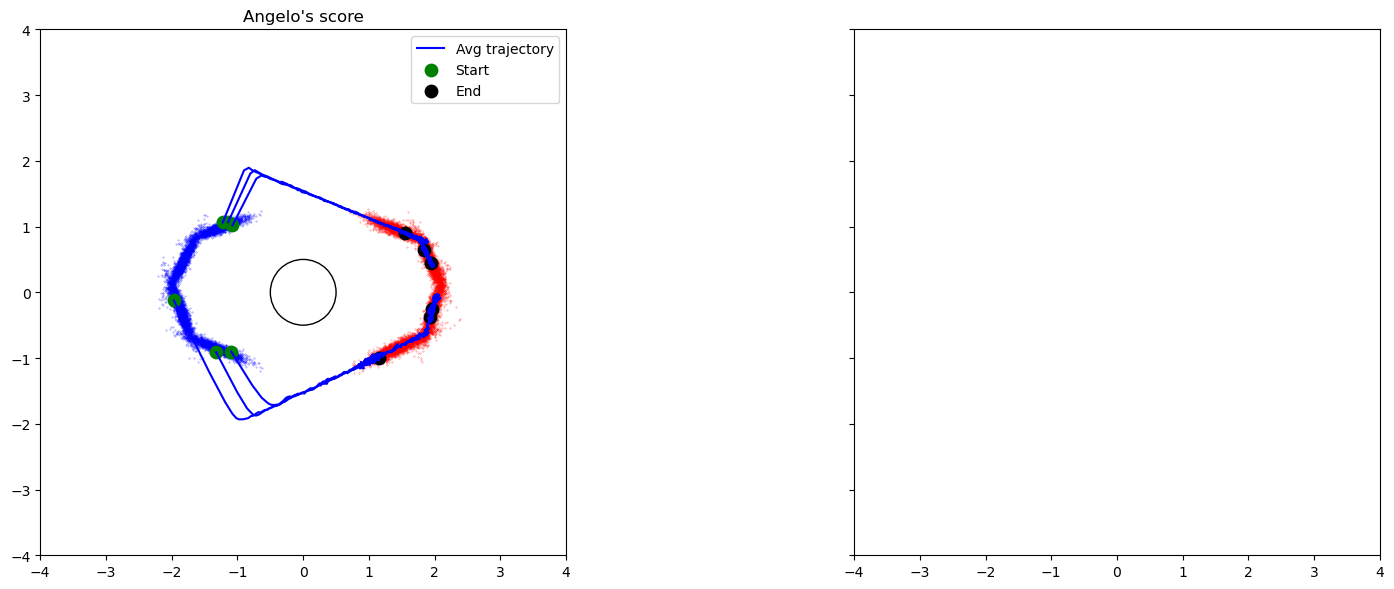

In [13]:
# ─── Plotting ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)

for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-4., 4.)
    ax.set_ylim(-4., 4.)

# Anglo's Score
axes[0].add_patch(plt.Circle((0,0), R, color='black', fill=False))
axes[0].scatter(initial_positions[:10000,0], initial_positions[:10000,1], s=0.1, alpha=0.5, color='blue')
axes[0].scatter(final_positions1[:10000,0], final_positions1[:10000,1], s=0.1, alpha=0.5, color='red')

for center in range(centers):
    axes[0].plot(avg_paths1[:, center, 0], avg_paths1[:, center, 1], 'b-', lw=1.5, label='Avg trajectory' if center == 0 else None)
    axes[0].scatter(avg_paths1[0, center, 0], avg_paths1[0, center, 1], color='green', s=80, label='Start'  if center == 0 else None)
    axes[0].scatter(avg_paths1[-1, center, 0], avg_paths1[-1, center, 1], color='black', s=80, label='End'  if center == 0 else None)
axes[0].set_title("Angelo's score")
axes[0].legend()

# Klaas' score
# axes[1].add_patch(plt.Circle((0,0), R, color='black', fill=False))
# axes[1].scatter(initial_positions[:10000,0], initial_positions[:10000,1], s=0.1, alpha=0.5, color='blue')
# axes[1].scatter(final_positions2[:10000,0], final_positions2[:10000,1], s=0.1, alpha=0.5, color='red')

# for center in range(centers):
#     axes[1].plot(avg_paths2[:, center, 0], avg_paths2[:, center, 1], 'b-', lw=1.5, label='Avg trajectory' if center == 0 else None)
#     axes[1].scatter(avg_paths2[0, center, 0], avg_paths2[0, center, 1], color='green', s=80, label='Start'  if center == 0 else None)
#     axes[1].scatter(avg_paths2[-1, center, 0], avg_paths2[-1, center, 1], color='black', s=80, label='End'  if center == 0 else None)
# axes[1].set_title("Klaas' score")
# axes[1].legend()

plt.savefig("PSRStochasticMethod.pdf")
plt.tight_layout()
plt.show()